In [27]:
IMAGE_ID = 'S1585-2_a'
ROI_X = 4820
ROI_Y = 1710
ROI_W = 128
ROI_H = 256


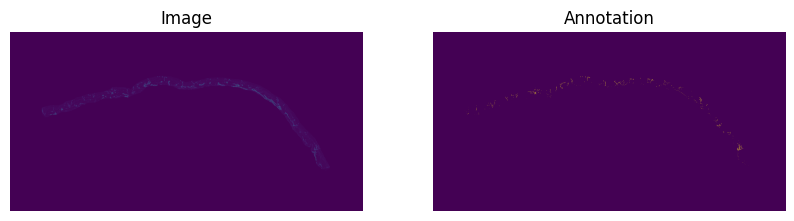

In [28]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import skimage as ski
import cv2

sample_id =  "S1585-2_a"

img = np.array(Image.open(f"../data/{IMAGE_ID}/roi_image.png"))
annotation = np.array(Image.open(f"../data/{IMAGE_ID}/roi_annotation.png").convert("L")).astype(np.uint8)

bg_tiny = ski.restoration.rolling_ball(img, radius=2)
bg = bg_tiny

fg_img = (img.astype(np.uint8) - bg.astype(np.uint8)).astype(np.uint8)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
fg_img = clahe.apply(fg_img)

_, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(fg_img)
ax[0].set_title("Image")
ax[0].axis('off')

ax[1].imshow(annotation)
ax[1].set_title("Annotation")
ax[1].axis('off')
plt.show()

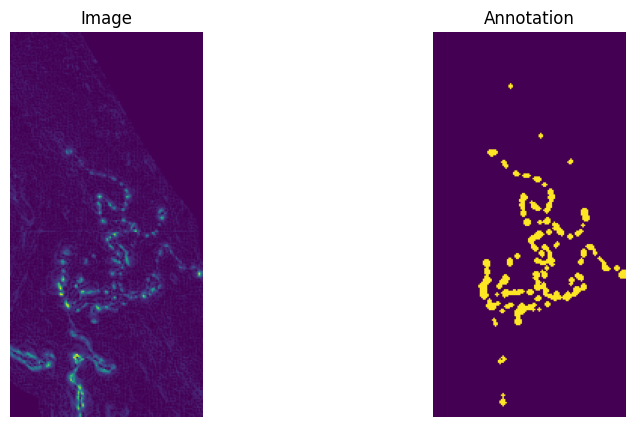

In [29]:

roi = fg_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W]
roi_annotation = annotation[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W]
# roi = fg_img
# roi_annotation = annotation

_, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(roi)
ax[0].set_title("Image")
ax[0].axis('off')

ax[1].imshow(roi_annotation)
ax[1].set_title("Annotation")
ax[1].axis('off')
plt.show()

0.0359030375594162 0.9537651321224604


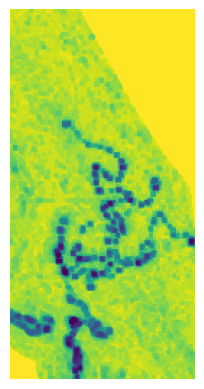

In [30]:
cost_map = roi.astype(np.float32)
cost_map = cv2.morphologyEx(((255 - roi.astype(np.float64)) / 255) ** 4, cv2.MORPH_ERODE, np.ones((3,3), np.float64))

print(cost_map.min(), cost_map.max())
plt.imshow(cost_map)
plt.axis('off')
plt.show()

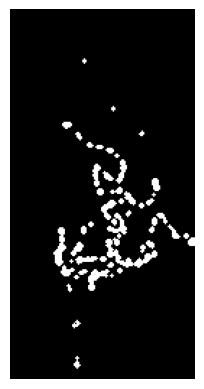

In [31]:
import cv2

opening_notation = roi_annotation.copy()
opening_notation[opening_notation > 0] = 255

# opening_notation = cv2.morphologyEx(opening_notation, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))

plt.imshow(opening_notation, cmap='gray')
plt.axis('off')
plt.show()

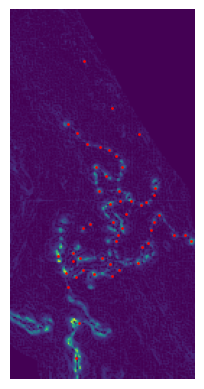

In [32]:
from typing import Tuple, Dict, Optional, List

notation_components = cv2.connectedComponentsWithStats(roi_annotation, connectivity=4)

seed_points: List[Tuple[int, int]] = []
for i in range(1, notation_components[0]):
    # Find the highest intensity point in each component
    component_mask = (notation_components[1] == i)
    ys, xs = np.where(component_mask)
    intensities = roi[ys, xs]
    max_idx = np.argmax(intensities)
    x = xs[max_idx]
    y = ys[max_idx]
    seed_points.append((y, x))  # (row, col) format


plt.imshow(roi)
for (y, x) in seed_points:
    plt.plot(x, y, 'ro', markersize=1)
plt.axis('off')
plt.show()

In [199]:
from typing import Tuple, List, Deque
from collections import deque
import heapq

l_bk = 20
alpha = 0.95
eta = 1e-3
l_AVE = 100
l_E = 700
P = cv2.morphologyEx(((255 - roi.astype(np.float64)) / 255) ** 20, cv2.MORPH_ERODE, np.ones((1,1), np.float64))
# P = np.exp(10 * (255 - roi.astype(np.float64)) / 255) - 1
print(P.min(), P.max())

def mppbt(seed):
        # seed = seed_points[3]  # Using the first seed point for demonstration
    NS_min = 5e-2
    rows, cols = P.shape
    I_BK = np.zeros((rows, cols), dtype=np.float64)  # Feature map for accumulation
    U = np.full((rows, cols), np.inf, dtype=np.float64)  # Accumulated cost
    U[seed] = 0.0

    parent: Dict[Tuple[int, int], Tuple[int, int]] = {}
    visited = np.zeros((rows, cols), dtype=bool)

    # Priority queue for Dijkstra
    heap = [(0.0, seed[0], seed[1])]

    # Stopping criterion variables
    l_SM = 0
    stop_propagation = False

    # For computing NS: store recent S values
    S_values: Deque[float] = deque(maxlen=l_AVE)
    S_max = 0.0


    iteration = 0
    min_points_before_stopping = 0  # Don't check stopping until we have enough points
    neighbors = [
    (-1, -1), (-1, 0), (-1, 1),
    (0, -1),          (0, 1),
    (1, -1),  (1, 0), (1, 1)
    ]
    neighbor_distances = np.array([
    np.sqrt(2), 1.0, np.sqrt(2),
    1.0,              1.0,
    np.sqrt(2), 1.0, np.sqrt(2)
    ])

    global_min_NS = 1.0
    NS_record = []
    reached_order = []
    while heap and not stop_propagation:
        # Get next point with minimum cost
        current_cost, r, c = heapq.heappop(heap)
        p = (r, c)
        
        if visited[p]:
            continue
        
        visited[p] = True
        reached_order.append(p)
        iteration += 1
        
        # ----- IMMEDIATELY backtrack from current point p -----
        backtrack_path = []
        current = p
        steps = 0
        
        while steps < l_bk and current != seed and current in parent:
            backtrack_path.append(current)
            current = parent[current]
            steps += 1
        
        if current != p or len(backtrack_path) == 0:
            backtrack_path.append(current)
        
        # Get p_bk^E (the last point in backtracking path)
        p_bk_E = backtrack_path[-1]
        
        # ----- IMMEDIATELY accumulate evidence at p_bk^E -----
        # Eq. (3): I_BK(p_bk^E) += 1 / (η + P(p_bk^E))
        I_BK[p_bk_E] += 1.0 / (eta + P[p_bk_E])
        
        # ----- COST RESETTING SCHEME -----
        # Key mechanism to solve shortcut and accumulation problems!
        # Reset U(p) to the cost difference between p and p_bk^E
        # This makes the cost represent "distance from nearest feature point"
        # instead of "distance from starting point"
        segment_cost = 0.0
        for i in range(len(backtrack_path) - 1):
            p_curr = backtrack_path[i]
            p_next = backtrack_path[i + 1]  # Parent (closer to p_s)
            # Euclidean distance between adjacent points (1.0 or sqrt(2))
            dist = np.sqrt((p_curr[0] - p_next[0])**2 + (p_curr[1] - p_next[1])**2)
            # Cost contribution: P(current point) * distance
            segment_cost += P[p_curr] * dist
        
        # Ensure U_reset is positive (can be zero or negative if p == p_bk^E)
        U_reset = max(segment_cost, eta)
        U[p] = U_reset
        
        # ----- IMMEDIATELY calculate Backtracking Speed S(p) -----
        # Eq. (4): S(p) = l_bk / (U(p) - U(p_bk^E))
        # After reset, this is simply: S(p) = actual_steps / U_reset
        actual_steps = len(backtrack_path) - 1 if len(backtrack_path) > 1 else 1
        
        # After cost resetting, U[p] is already the cost from p_bk^E to p
        # So S(p) = actual_steps / U[p] (which is U_reset)
        cost_diff = U_reset  # This is U(p) - U(p_bk^E)
        
        # Skip S/NS calculation for points too close to start
        if cost_diff > eta and actual_steps > 0:
            S_p = actual_steps / cost_diff
        else:
            S_p = 0  # Will be skipped in NS calculation
        
        # Only update S_max and S_values for valid S values
        if S_p > 0:
            if S_max == 0 or S_p > S_max:
                S_max = S_p
            S_values.append(S_p)
        
        # ----- IMMEDIATELY calculate Normalized Average Speed NS(p) -----
        # Eq. (5): NS(p) = S_bar(p, l_AVE) / S_max(p)
        # Only check stopping after we have enough valid S values
        if len(S_values) >= min_points_before_stopping and S_max > 0:
            S_bar = sum(S_values) / len(S_values)
            NS_p = S_bar / S_max
            NS_record.append(NS_p)
            if NS_p < global_min_NS:
                global_min_NS = NS_p
            # ----- IMMEDIATELY check Stopping Criterion -----
            if NS_p < NS_min:
                l_SM += 1
            else:
                l_SM = 0
                
            NS_min = global_min_NS  # Update to current minimum
            
            if l_SM >= l_E:
                stop_propagation = True
                print(f"  Stopping at iteration {iteration}: l_SM={l_SM} >= l_E={l_E}")
        else:
            NS_p = 1.0  # Default value before we have enough data
        
        # ----- Expand neighbors (Dijkstra step) -----
        if not stop_propagation:
            for i, (dr, dc) in enumerate(neighbors):
                nr, nc = r + dr, c + dc
                
                if not (0 <= nr < rows and 0 <= nc < cols):
                    continue
                if visited[nr, nc]:
                    continue
                
                step_cost = P[nr, nc] * neighbor_distances[i]
                new_cost = U[p] + step_cost
                
                if new_cost < U[nr, nc]:
                    U[nr, nc] = new_cost
                    parent[(nr, nc)] = p
                    heapq.heappush(heap, (new_cost, nr, nc))
        
        print(f"  Iter {iteration}: NS={NS_p:.4f}, NS_min={NS_min:.4f}, l_SM={l_SM}")
    I_BK_alpha = np.quantile(I_BK[I_BK > 0], alpha)
    I_C = (I_BK > I_BK_alpha).astype(np.uint8)
    I_C_refined = I_C.copy()
    for p in zip(*np.where(I_BK > 0)):
        backtrack_path = []
        current = p
        steps = 0
        
        while steps < l_bk and current in parent and current != seed:
            # if current in :
            #     break
            
            backtrack_path.append(current)
            current = parent[current]
            steps += 1
        
        if current != p:
            backtrack_path.append(current)
        
        if len(backtrack_path) > 0:
            p_bk_E = backtrack_path[-1]
            if I_C[p_bk_E] == 1:
                for pbk in backtrack_path:
                    I_C_refined[pbk] = 1
    
    return I_BK, U, I_C_refined, parent
            
            

5.965625233247293e-08 0.789236581762256


In [200]:
# I_BKS = np.zeros((roi.shape[0], roi.shape[1]), dtype=np.float64)
I_CS = []
I_BKS = []
U_S = []
voted_parents: Dict[Tuple[int, int], Dict[Tuple[int, int], int]] = {}

sorted_seed_points = sorted(seed_points, key=lambda p: p[0], reverse=True)
selected_seed = sorted_seed_points[2]
I_BK, U, I_C_refined, parent = mppbt(selected_seed)



  Iter 1: NS=1.0000, NS_min=0.0500, l_SM=0
  Iter 2: NS=1.0000, NS_min=1.0000, l_SM=0
  Iter 3: NS=0.9999, NS_min=0.9999, l_SM=1
  Iter 4: NS=0.9247, NS_min=0.9247, l_SM=2
  Iter 5: NS=0.8703, NS_min=0.8703, l_SM=3
  Iter 6: NS=0.8270, NS_min=0.8270, l_SM=4
  Iter 7: NS=0.7982, NS_min=0.7982, l_SM=5
  Iter 8: NS=0.7989, NS_min=0.7982, l_SM=0
  Iter 9: NS=0.8189, NS_min=0.7982, l_SM=0
  Iter 10: NS=0.8206, NS_min=0.7982, l_SM=0
  Iter 11: NS=0.7731, NS_min=0.7731, l_SM=1
  Iter 12: NS=0.7924, NS_min=0.7731, l_SM=0
  Iter 13: NS=0.8063, NS_min=0.7731, l_SM=0
  Iter 14: NS=0.8059, NS_min=0.7731, l_SM=0
  Iter 15: NS=0.7863, NS_min=0.7731, l_SM=0
  Iter 16: NS=0.7662, NS_min=0.7662, l_SM=1
  Iter 17: NS=0.7485, NS_min=0.7485, l_SM=2
  Iter 18: NS=0.7557, NS_min=0.7485, l_SM=0
  Iter 19: NS=0.7360, NS_min=0.7360, l_SM=1
  Iter 20: NS=0.7183, NS_min=0.7183, l_SM=2
  Iter 21: NS=0.7217, NS_min=0.7183, l_SM=0
  Iter 22: NS=0.7149, NS_min=0.7149, l_SM=1
  Iter 23: NS=0.7165, NS_min=0.7149, l_SM

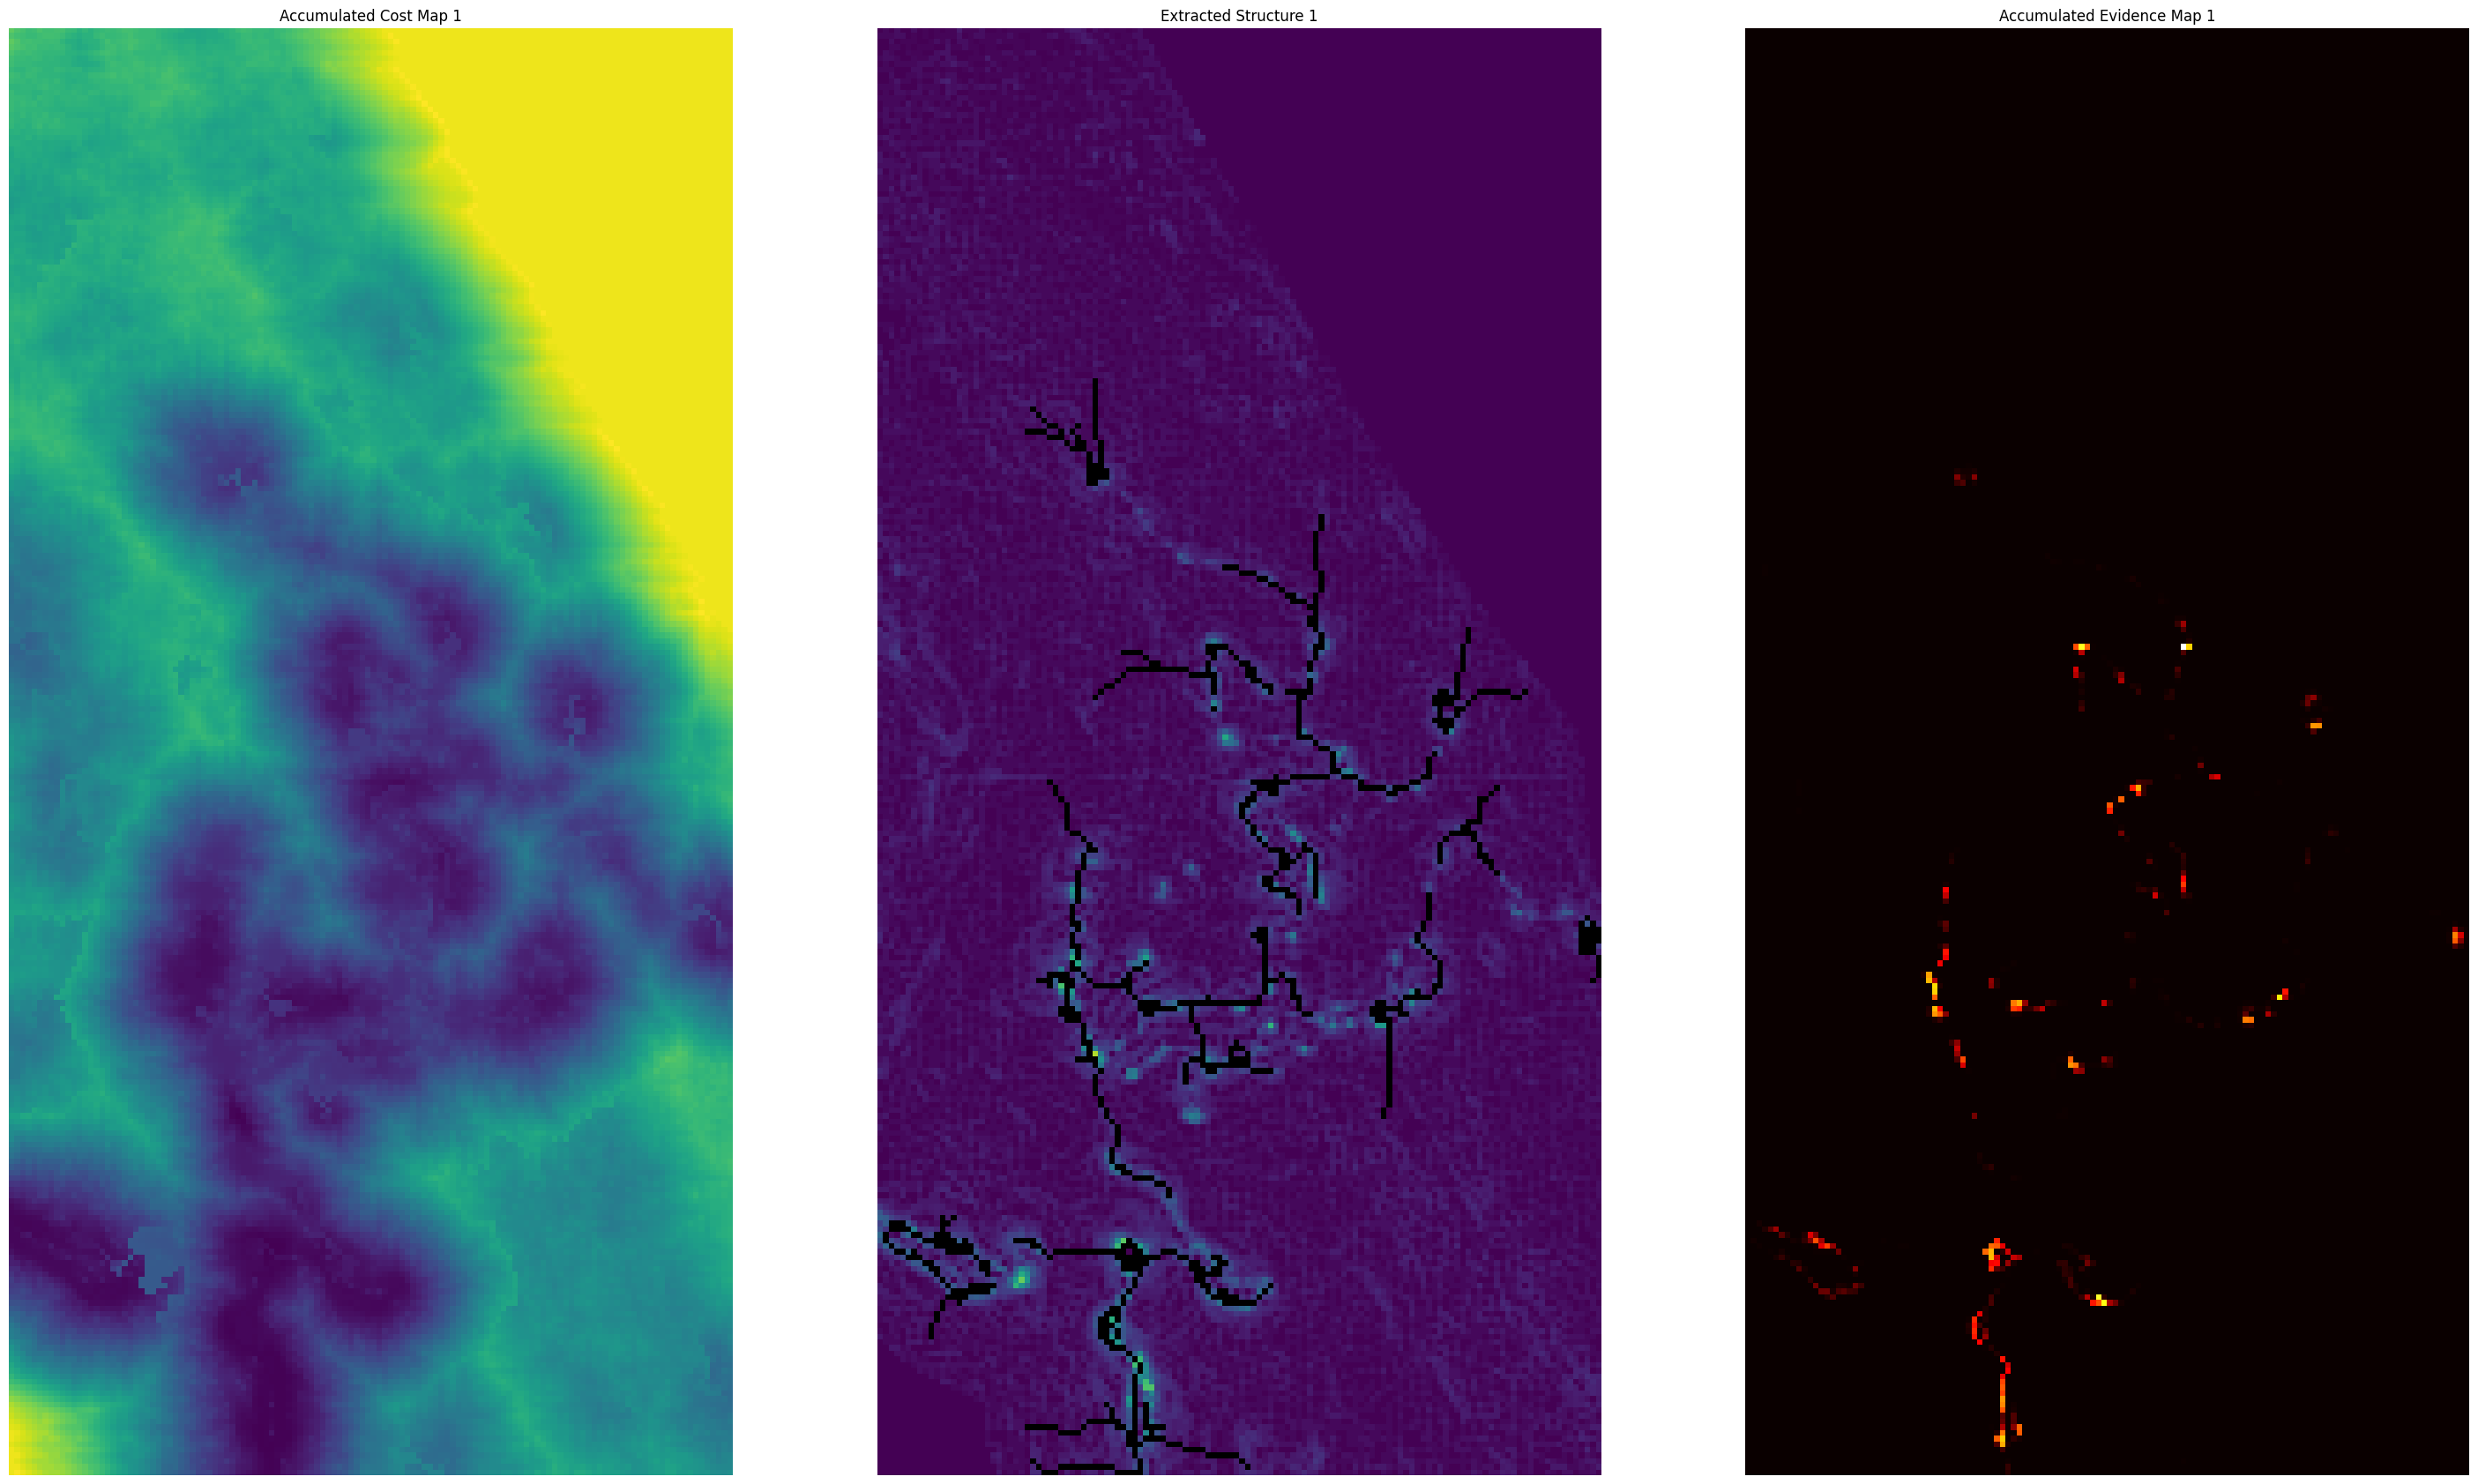

In [201]:
image_per_row = 2
h_per_image = 24 
w_per_image = 12


_, ax = plt.subplots(1, 3, figsize=(w_per_image * 3, h_per_image))

axu = ax[0]
axu.imshow(U)

axu.set_title(f"Accumulated Cost Map {1}")
axu.axis('off')
axic = ax[1]
axic.imshow(roi)
axic.imshow(np.ma.masked_where(I_C_refined == 0, I_C_refined), cmap='gray', alpha=1)
axic.set_title(f"Extracted Structure {1}")
axic.axis('off')


axib = ax[2]
# axib.imshow(roi)
axib.imshow(I_BK, cmap='hot')
# axib.imshow(np.ma.masked_where(I_BK == 0, I_BK), cmap='hot', alpha=0.5)
axib.set_title(f"Accumulated Evidence Map {1}")
axib.axis('off')
plt.show()

In [202]:
# 基本檢查
cost_map = P
print(f"Shape: {cost_map.shape}")
print(f"Dtype: {cost_map.dtype}")
print(f"Min: {cost_map.min()}")
print(f"Max: {cost_map.max()}")
print(f"Mean: {cost_map.mean()}")
print(f"有 NaN? {np.isnan(cost_map).sum()}")
print(f"有 Inf? {np.isinf(cost_map).sum()}")
print(f"有 0? {(cost_map == 0).sum()}")

# 看 unique 值的數量
print(f"Unique 值數量: {len(np.unique(cost_map))}")

Shape: (256, 128)
Dtype: float64
Min: 5.965625233247293e-08
Max: 0.789236581762256
Mean: 0.5779452881383642
有 NaN? 0
有 Inf? 0
有 0? 0
Unique 值數量: 121


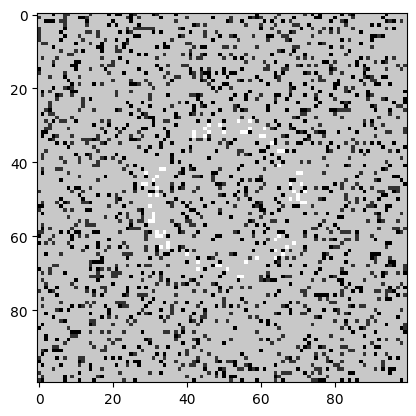

In [203]:
from skimage.graph.mcp import MCP_Geometric
test_image = np.full((100, 100), 50, dtype=np.float32)
test_image = cv2.circle(test_image, (50, 50), 20, 255, 3)
test_image = cv2.rectangle(test_image, (30, 30), (40, 40), 10, -1)
noise = np.random.choice([0, 1], size=test_image.shape, p=[0.10, 0.90])
salt_pepper = np.random.choice([0, 1], size=test_image.shape, p=[0.1, 0.9])
test_image[noise == 1] = salt_pepper[noise == 1] * 200
plt.imshow(test_image, cmap='gray')


In [204]:
from skimage.transform import rescale


mcp = MCP_Geometric(rescale(P, 4), fully_connected=True)
cumulative_costs, traceback = mcp.find_costs(starts=[(selected_seed[0]*4, selected_seed[1]*4)])



0.0 397.58328130469374


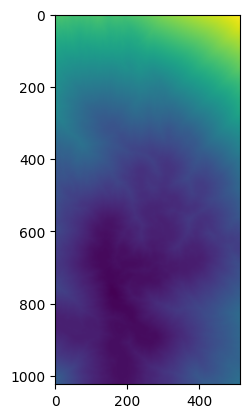

In [205]:
print(cumulative_costs.min(), cumulative_costs.max())
plt.imshow(cumulative_costs)